<a href="https://colab.research.google.com/github/harveenkaur282-web/ai-ml_labs/blob/main/DIABETES_PREDICTION_USING_SVM1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

In [5]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df['target'] = (df['target'] > df['target'].median()).astype(int)
X = df.drop(columns=['target'])
y = df['target']
print(X)
print(y)

          age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  
0   -0.002592  0.019907 -0.017646  
1  

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42) # RBF Kernel → Handles non-linearly separable data. probability=True → Enables AUC-ROC computation
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

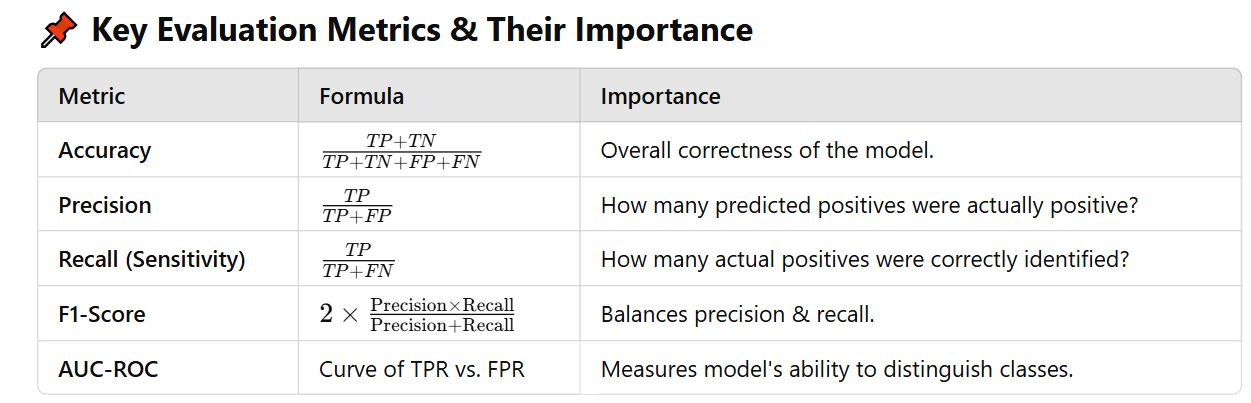

Accuracy (Train): 0.813
Accuracy (Test): 0.742

Precision (Train): 0.814
Precision (Test): 0.714

Recall (Train): 0.814
Recall (Test): 0.795

F1-Score (Train): 0.814
F1-Score (Test): 0.753

AUC-ROC (Train): 0.813
AUC-ROC (Test): 0.742



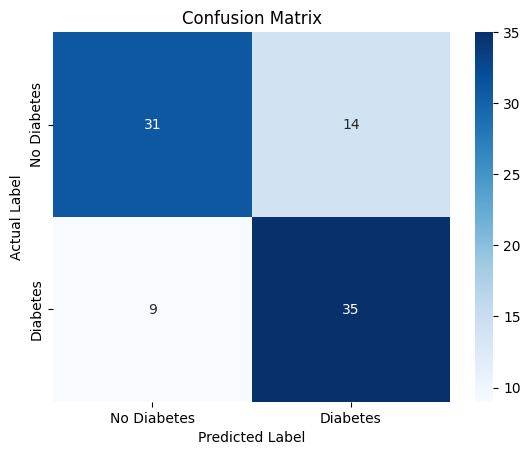

In [9]:
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)
metrics = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "F1-Score": f1_score,
    "AUC-ROC": roc_auc_score
}
for metric_name, metric_func in metrics.items():
    print(f"{metric_name} (Train): {metric_func(y_train, y_train_pred):.3f}")
    print(f"{metric_name} (Test): {metric_func(y_test, y_test_pred):.3f}\n")

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [10]:
report = classification_report(y_test, y_test_pred)
print(report)

              precision    recall  f1-score   support

           0       0.78      0.69      0.73        45
           1       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



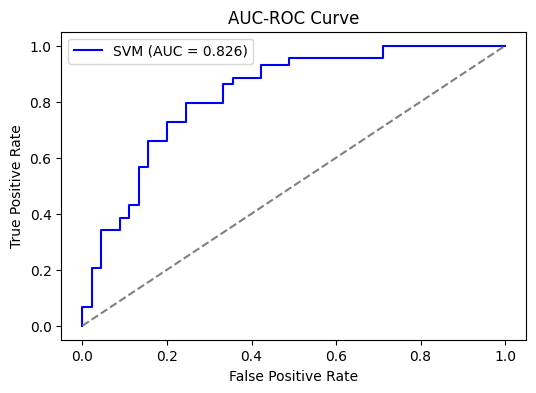

In [11]:
y_train_prob = svm_model.predict_proba(X_train_scaled)[:, 1]
y_test_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label="SVM (AUC = {:.3f})".format(roc_auc_score(y_test, y_test_prob)))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()

In [12]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

if train_acc > test_acc + 0.05:
    print("The model is Overfitting! (High Training Accuracy, Low Test Accuracy)")
elif train_acc < 0.7 and test_acc < 0.7:
    print("The model is Underfitting! (Both Accuracies are Low)")
else:
    print("The model has a good balance (Generalization).")

The model is Overfitting! (High Training Accuracy, Low Test Accuracy)


 **How to Detect?**

1. Overfitting → High training accuracy, low test accuracy.
2. Underfitting → Both train & test accuracies are low.
3. Overfitting detected? Reduce complexity (e.g., regularization).
4. Underfitting detected? Increase complexity (e.g., use non-linear kernels).

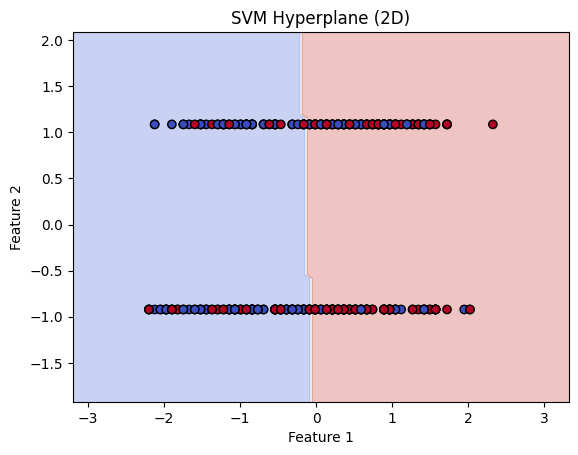

In [13]:
X_vis = X_train_scaled[:, :2]
svm_vis = SVC(kernel='linear')
svm_vis.fit(X_vis, y_train)
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_train, edgecolors='k', cmap="coolwarm")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Hyperplane (2D)")
plt.show()